In [3]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as con
from scipy.special import erf, erfi
from numpy import sqrt, pi, exp
import scipy
from scipy.optimize import fsolve
import astropy.constants as acon


In [ ]:
def speed(v):
    return sqrt(np.sum(v**2, axis = 1))

def Nesc_gaussian(sig, v_esc):
    # Got this from github.com/cajohare/DarkShards/blob/master/code/HaloFuncs.py
    # sig = 1d dispersion
    # v_esc = escape velocity
    return erf(v_esc/(sqrt(2)*sig)) - \
    sqrt(2.0/pi)*(v_esc/sig)*exp(-v_esc**2.0/(2.0*sig**2.0))

def fv_gaussian(v, sig, v_c, v_esc = 528.0):
    constants = 2 * pi * sig**2
    constants = 1 / (np.power(constants, 3/2))
    
    N_esc = Nesc_gaussian(sig, v_esc)
    f = np.exp(-(speed(v - v_c)**2) / 2 / (sig**2)) / N_esc
    
    return constants * f

def speedDistGaussian(v, sig, v_c, v_esc= 528.0):
    constants = v / (sqrt(2*pi) * v_c * sig)
    
    # got this from ciaran's fine grained dark matter paper, is v_e supposed to be v_c?
    f1 = exp(- (v**2 + v_c**2 - 2*v*v_c) / (2 * sig**2))
    f2 = exp(- (v**2 + v_c**2 + 2*v*v_c) / (2 * sig**2))
    
    N_esc = Nesc_gaussian(sig, v_esc) # what is N_esc?
    #print(N_esc)
    
    return (f1 - f2) * constants / N_esc

\begin{equation}
    \rho f(\mathbf{v},t) = \rho_\infty \~f(\mathbf{v_\odot + v_\infty[v + V_\oplus]},t)
\end{equation}

In [295]:
v_sun = np.array([12.9, 245.6, 7.78])
v_earth = np.array([0, 0, 0])
v_str = np.array([100, 0, 0])

v_c = v_sun + v_str
# note that v_i = v_infty[v_f + v_earth]
sig = 1

num = 10000
v_i = [np.linspace(v_c[i] - 25, v_c[i] + 25, num) for i in range(3)]

v_i = np.column_stack(v_i)
p_i = fv_gaussian(v_i, sig, v_c)
p_i = p_i / np.sum(p_i)

p_i = speedDistGaussian(speed(v_i), sig, np.sqrt(np.sum(v_c*v_c)))
p_i = p_i / np.sum(p_i)


In [30]:
def grav(x):
    return - acon.G.value * 1e-9 * acon.M_sun.value / 149600000

def rotate(t):
    return np.array(([np.cos(t), 0, np.sin(t)],
              [0, 1, 0],
              [-np.sin(t), 0, np.cos(t)]))

def v_inf(v, t):
    r = np.array([rotate(t) @ v_c]) # in km
    d = np.sqrt(np.sum(v*v) + 2 * grav(r))

    vi = d * d * v \
        -  d * r / speed(r) * grav(r) \
        - d * v * (np.dot(v, r.T / speed(r)))
    
    vi = vi / (d*d - grav(r) - d * np.dot(v, r.T / speed(r)))
    
    return vi

In [337]:
acon.GM_sun

<<class 'astropy.constants.iau2015.IAU2015'> name='Nominal solar mass parameter' value=1.3271244e+20 uncertainty=0.0 unit='m3 / s2' reference='IAU 2015 Resolution B 3'>

In [452]:
num = 10000
sig = 0.5
t = np.pi / 18

#r = np.array([10, 0, 12])
r = np.array([rotate(t) @ v_c])
r = -v_c
r = r / np.sqrt(np.sum(r*r)) * 149600000
rs = 149600000

def speedf1(v, sig, x = r, w = v_c):
    ws = np.sqrt(np.sum(w * w))
    f1 = exp(- (v**2 + ws**2 - 2*v*ws) / (2 * sig**2))
    f2 = exp(- (v**2 + ws**2 + 2*v*ws) / (2 * sig**2))
    sinh = (f1 - f2) / 2

    xs = np.sqrt(np.sum(x*x))

    frac = np.sum(w * x / xs) + v
    frac = frac / (xs * ws)
    fact = np.sqrt(2 / np.pi) * acon.GM_sun.value * 1e-9 / sig / sig / sig

    return fact * frac * sinh

from scipy.integrate import quad

quad(speedf1, 0, 500, args =(sig))[0] + 1



0.9999999961461046

In [443]:
sig = 0.1

1 + 2 * acon.GM_sun.value * 1e-9 / sig / sig / rs

177424.04812834226

In [463]:
w = np.sqrt(np.sum(v_c*v_c))

rs = 149600000
factor = acon.GM_sun.value * 1e-9 / (w * w * rs)

t = 0
sig = 0.5

expres = 4 * pi * w * w / (2 * np.pi * sig* sig) * np.exp(rs * w * (np.cos(t) - 1) / sig / sig) + 1

factor * expres + 1



7097.93405640876

In [333]:
quad(speedDistGaussian, 0, 400, args =(sig, np.sqrt(np.sum(v_c*v_c))))

(1.0000000000025258, 5.287743777100089e-10)

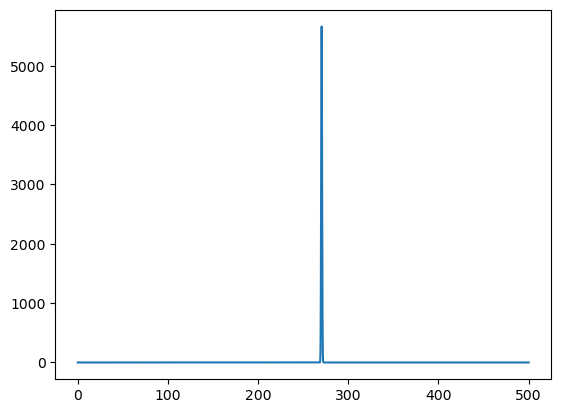

In [334]:
v = np.linspace(0, 500, num)
plt.plot(v, speedf1(v,sig))

In [ ]:
v = np.linspace(0, 400, num)
f1 = 

0.39894079021130485

In [151]:
np.sum(speedDistGaussian(v, sig, np.sqrt(np.sum(v_c*v_c))))

24.997500000033778

In [46]:
p_s

array([nan, nan, nan, ..., nan, nan, nan])

In [31]:
def func(v, vi , t):
    return (v_inf(v,t) - vi)[0]

v_f = []
ang = np.deg2rad(0)
for vi in v_i:
    root = fsolve(func, [25,25, 25], args=(vi,ang))
    v_f.append(root)
v_f = np.array(v_f)

/tmp/ipykernel_548/3369449450.py:11: RuntimeWarning: invalid value encountered in sqrt
  d = np.sqrt(np.sum(v*v) + 2 * grav(r))
/tmp/ipykernel_548/2244760551.py:7: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last five Jacobian evaluations.
  root = fsolve(func, [25,25, 25], args=(vi,ang))
/tmp/ipykernel_548/2244760551.py:7: RuntimeWarning: The number of calls to function has reached maxfev = 800.
  root = fsolve(func, [25,25, 25], args=(vi,ang))


In [2]:
def speedf1(v, x, w, sig):
    ws = np.sqrt(np.sum(w * w))
    sinh = np.sinh(v*ws / sig**2)
    ex = np.exp(- (v**2 + ws**2) / 2 / sig / sig)
    frac = np.sum(w * x) + v
    frac = frac / (np.sqrt(np.sum(x*x)) * ws)
    fact = np.sqrt(2 / np.pi) * acon.G.value * 1e-9 * acon.M_sun.value / 149600000
    return fact * frac * sinh * ex